# Phase 1 : Business Understanding

## Problem Statement

While traditional decision trees and even ensemble methods such as Random Forests remain widely used in machine learning, they exhibit important limitations when dealing with high-dimensional datasets, noisy variables, or small node sizes during tree construction. In such situations, the splitting decisions become increasingly unstable and may approach random behavior, reducing the model’s predictive quality and its ability to correctly identify the most relevant variables. The RLT method was specifically designed to address these issues: it enhances split selection through a reinforcement learning mechanism that considers long term rewards, progressively removes uninformative variables through a variable muting procedure, and allows for more flexible linear-combination splits. By evaluating RLT across a diverse set of real world classification and regression tasks, the goal is to determine whether it provides improved stability, clearer interpretability, and superior predictive performance compared to classical tree-based methods.

### Business Objective 1 : Improve the accuracy of tree-based decision systems


In many domains (healthcare, finance, industry), ensemble models such as Random Forests may lose accuracy when data are complex or high-dimensional.
The goal is to explore a new method  "Reinforcement Learning Trees (RLT) " to improve predictive performance across diverse real-world contexts.

### Business Objective 2 :Reduce the impact of noisy variables on decision making

Real datasets often contain noise and irrelevant features.
A key business objective is to develop a more stable model capable of focusing on truly informative variables, reducing errors, and improving interpretability.

### Business Objective 3 :Optimize computation time and efficiency for high dimensional datasets

Many industries work with large-scale datasets (high p).
The objective is to assess whether RLT offers a better trade-off between accuracy, training speed, and scalability compared with traditional models.

### Data Science Objective 1 : Evaluate RLT performance across diverse tasks

Test RLT on multiple datasets (classification and regression) to assess:

-predictive accuracy

-stability

-sensitivity to noise

-ability to detect complex interactions.

### Data Science Objective 2 : Analyze the selection of important variables

Study how RLT:

-identifies the most informative variables,

-mutes (removes) noisy variables,

-protects strong variables during tree construction.

Goal: demonstrate that RLT strengthens the signal and reduces noise.

### Data Science Objective 3 : Compare RLT with classical models and propose an improvement


Compare RLT with:

-Random Forests

-Gradient Boosting 

-BART 

to evaluate: accuracy, robustness, performance when p is large, quality of variable importance.

# Phase 2 : Data Understanding

In [251]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [252]:
bc = pd.read_csv("BreastCanDT.csv")

In [253]:
bc.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [254]:
print(" Info  : ")
bc.info()


 Info  : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

In [255]:
# taille du dataset
bc.shape

(569, 33)

In [256]:
bc.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [257]:
# Vérifier valeurs manquantes
missing = bc.isnull().sum()
print("Colonnes avec valeurs manquantes :")
print(missing)

Colonnes avec valeurs manquantes :
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
frac

In [258]:
#suppression de la colonne unamed :32 vide 
bc = bc.drop("Unnamed: 32", axis=1)


In [259]:
bc.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## distribution de la cible (diagnosis)

In [261]:
bc['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [262]:
bc['diagnosis'].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [263]:
#encoder diagnosis
le = LabelEncoder()
bc['diagnosis'] = le.fit_transform(bc['diagnosis'])


In [264]:
bc['diagnosis'].unique()


array([1, 0])

In [265]:
bc['diagnosis'].value_counts()



diagnosis
0    357
1    212
Name: count, dtype: int64

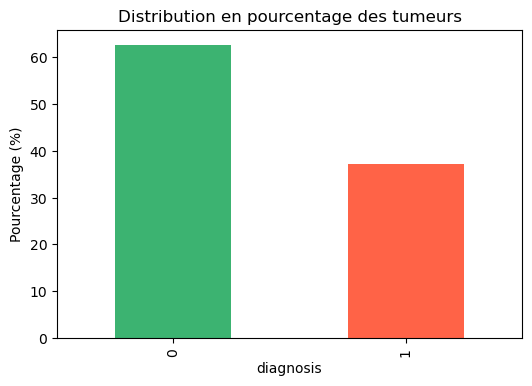

In [266]:
plt.figure(figsize=(6,4))
(bc['diagnosis'].value_counts(normalize=True) * 100).plot(kind='bar', color=['#3CB371','#FF6347'])
plt.title("Distribution en pourcentage des tumeurs")
plt.ylabel("Pourcentage (%)")
plt.show()

Interprétation: On observe un déséquilibre  entre les deux classes, avec une majorité de cas bénins (0).

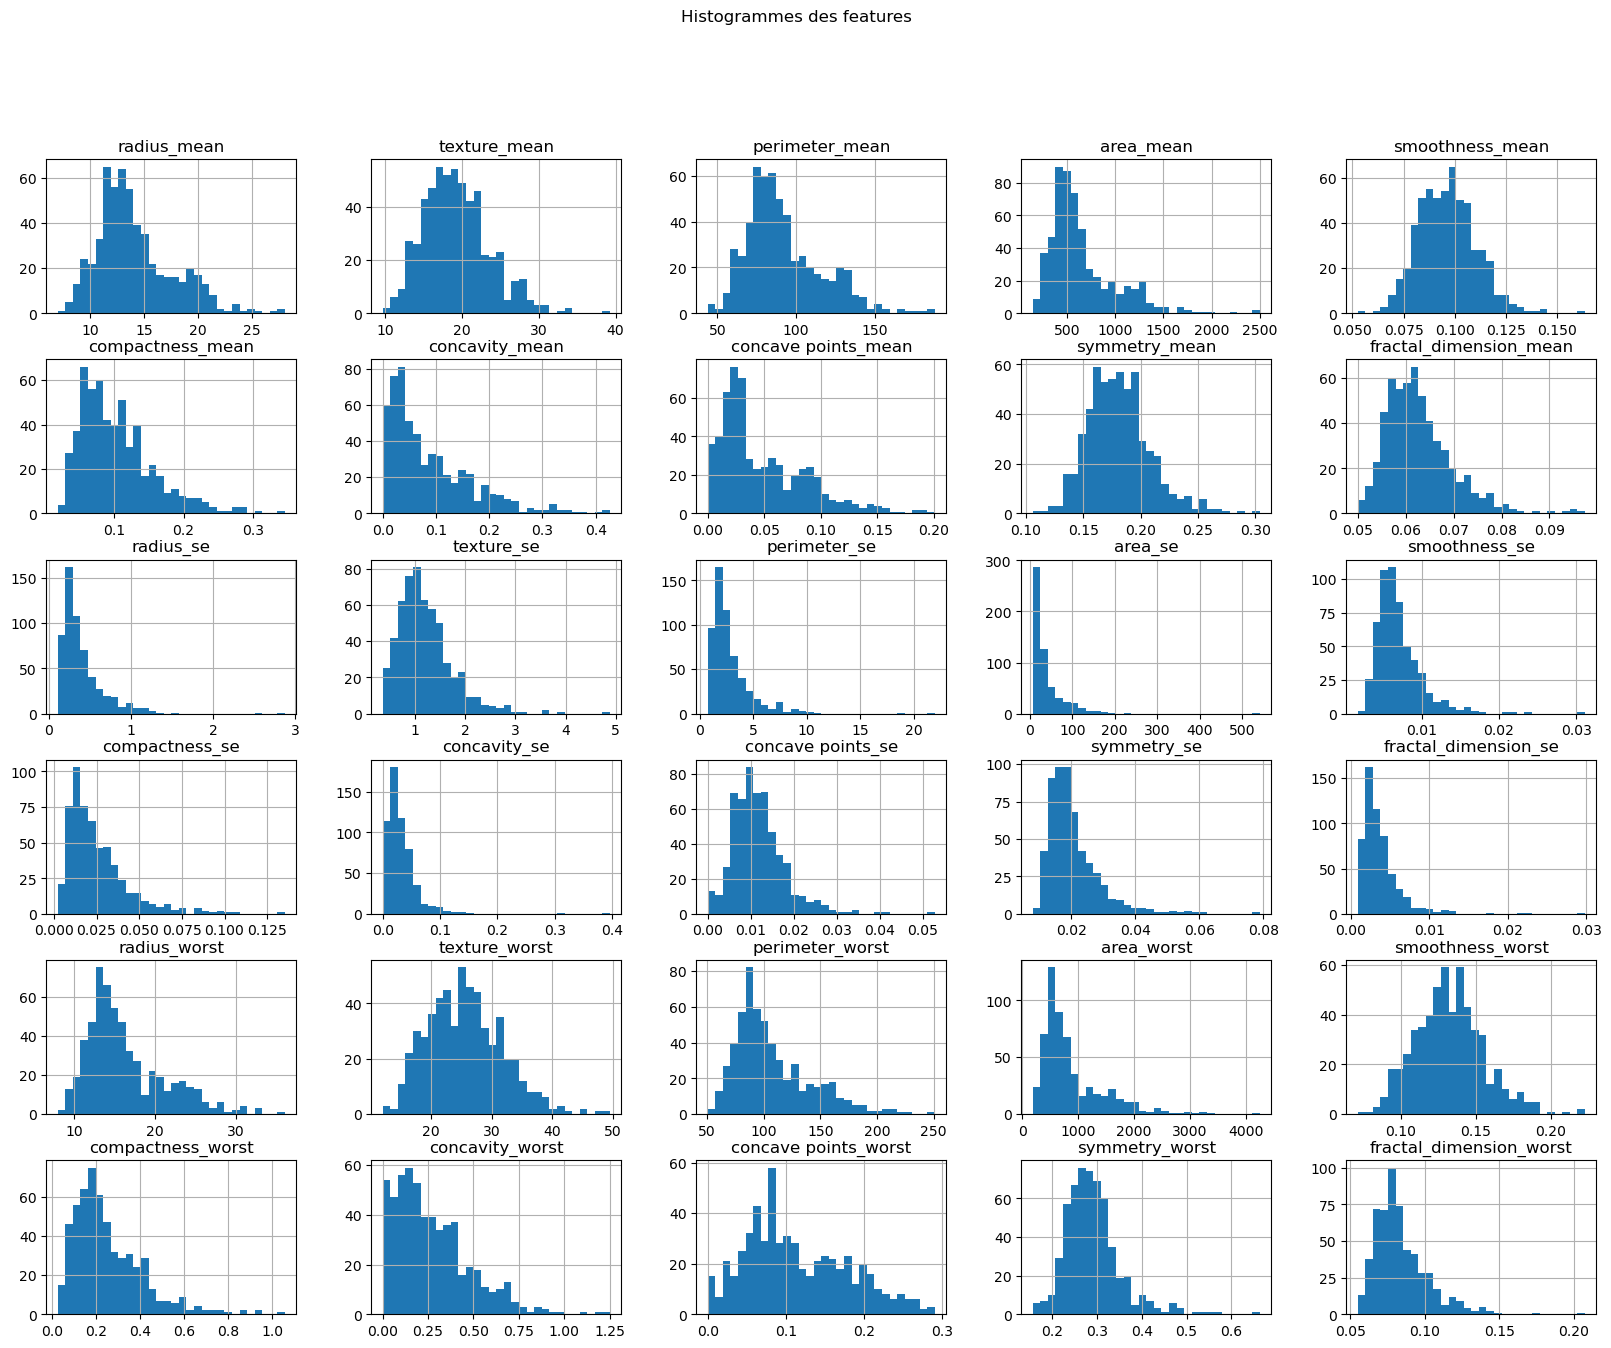

In [268]:
#Histogrammes pour voir la distribution
features = bc.columns[2:]  # ignorer id et diagnosis
bc[features].hist(bins=30, figsize=(20,15))
plt.suptitle("Histogrammes des features")
plt.show()


Interprétation: Les histogrammes montrent la distribution des valeurs pour chaque feature du dataset. Les Pics isolés présentent les outliers ou des groupes distincts.

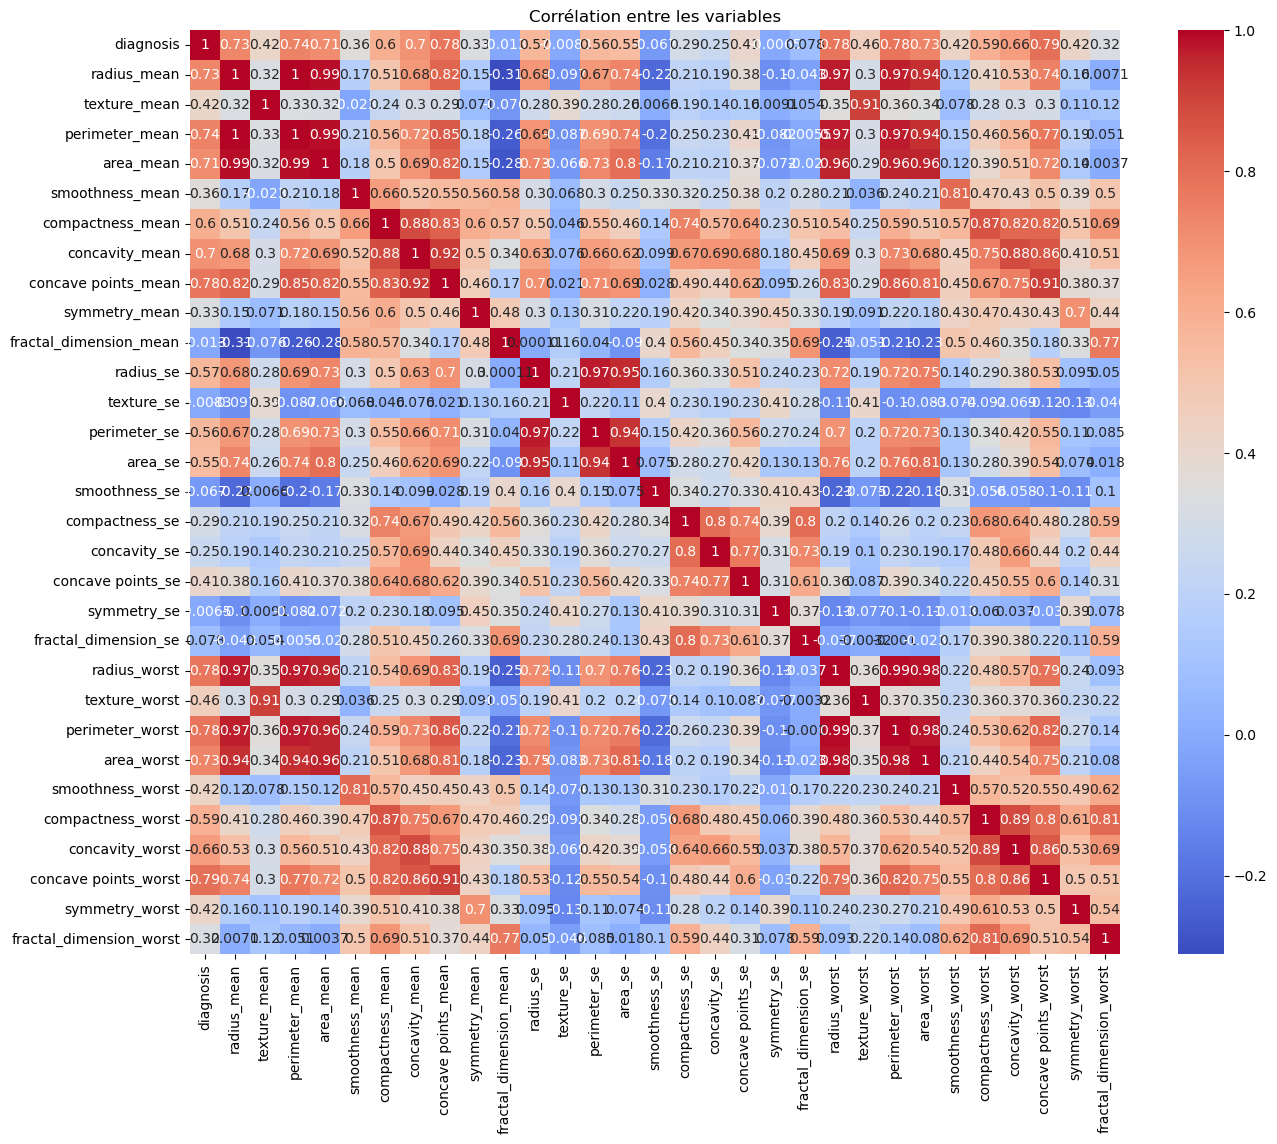

In [270]:
#Matrice de corrélation 

corr_matrix = bc.drop(columns=['id']).corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables")
plt.show()

Interprétation: On observe que radius_mean, perimeter_mean, area_mean sont corrélées positivement (proche de +1)
 car elles décrivent toutes la taille de la tumeur. Les variables évoluent en sens inverse : quand l’une augmente, l’autre diminue sont corrélées négativement (proche de -1).

In [272]:
#Table de corrélation
corr_target = corr_matrix['diagnosis'].sort_values(ascending=False)
corr_target

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

Interprétation:

L’analyse des corrélations entre les différentes variables et la variable cible diagnosis montre que certaines mesures des tumeurs sont fortement corrélées . Les variables les plus corrélées positivement, telles que concave points_worst (0,79), perimeter_worst (0,78), concave points_mean (0,78), radius_worst (0,78) ou encore perimeter_mean (0,74), indiquent que les tumeurs malignes ont tendance à présenter des valeurs plus élevées pour ces caractéristiques.

En revanche, certaines variables comme fractal_dimension_se, symmetry_se ou smoothness_se présentent des corrélations proches de zéro, ce qui suggère qu’elles apportent peu d’information pour distinguer les tumeurs.

In [274]:
# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bc.drop(columns=['id','diagnosis']))


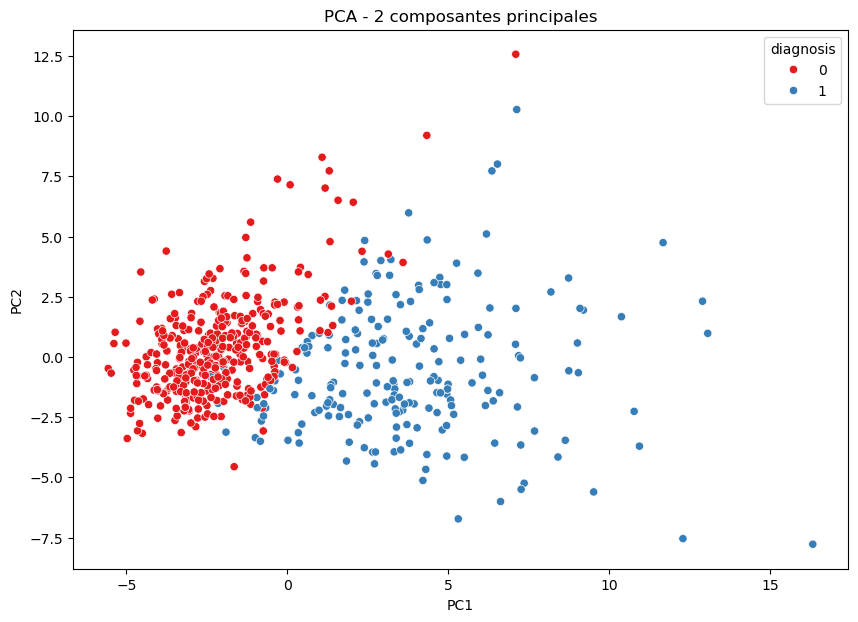

Variance expliquée par PC1 et PC2 : [0.44272026 0.18971182]
PC1 : 44.27%
PC2 : 18.97%
Variance cumulée PC1+PC2 : 63.24%


In [275]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=bc['diagnosis'], palette='Set1')
plt.title('PCA - 2 composantes principales')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Pourcentage de variance expliquée par chaque composante
print("Variance expliquée par PC1 et PC2 :", pca.explained_variance_ratio_)

# En pourcentage arrondi
print("PC1 : {:.2f}%".format(pca.explained_variance_ratio_[0]*100))
print("PC2 : {:.2f}%".format(pca.explained_variance_ratio_[1]*100))

# Variance cumulée (PC1 + PC2)
print("Variance cumulée PC1+PC2 : {:.2f}%".format(sum(pca.explained_variance_ratio_)*100))


Interprétation de PC1 et PC2 :
Les deux premières composantes principales (PC1 et PC2) expliquent ensemble 63,24 % de la variance totale du dataset. PC1 montre 44,27 % de la variance qui reflète la  différence entre les tumeurs bénignes et malignes, tandis que PC2 qui explique 18,97 % de la variance, apporte une information supplémentaire pour la distinction.

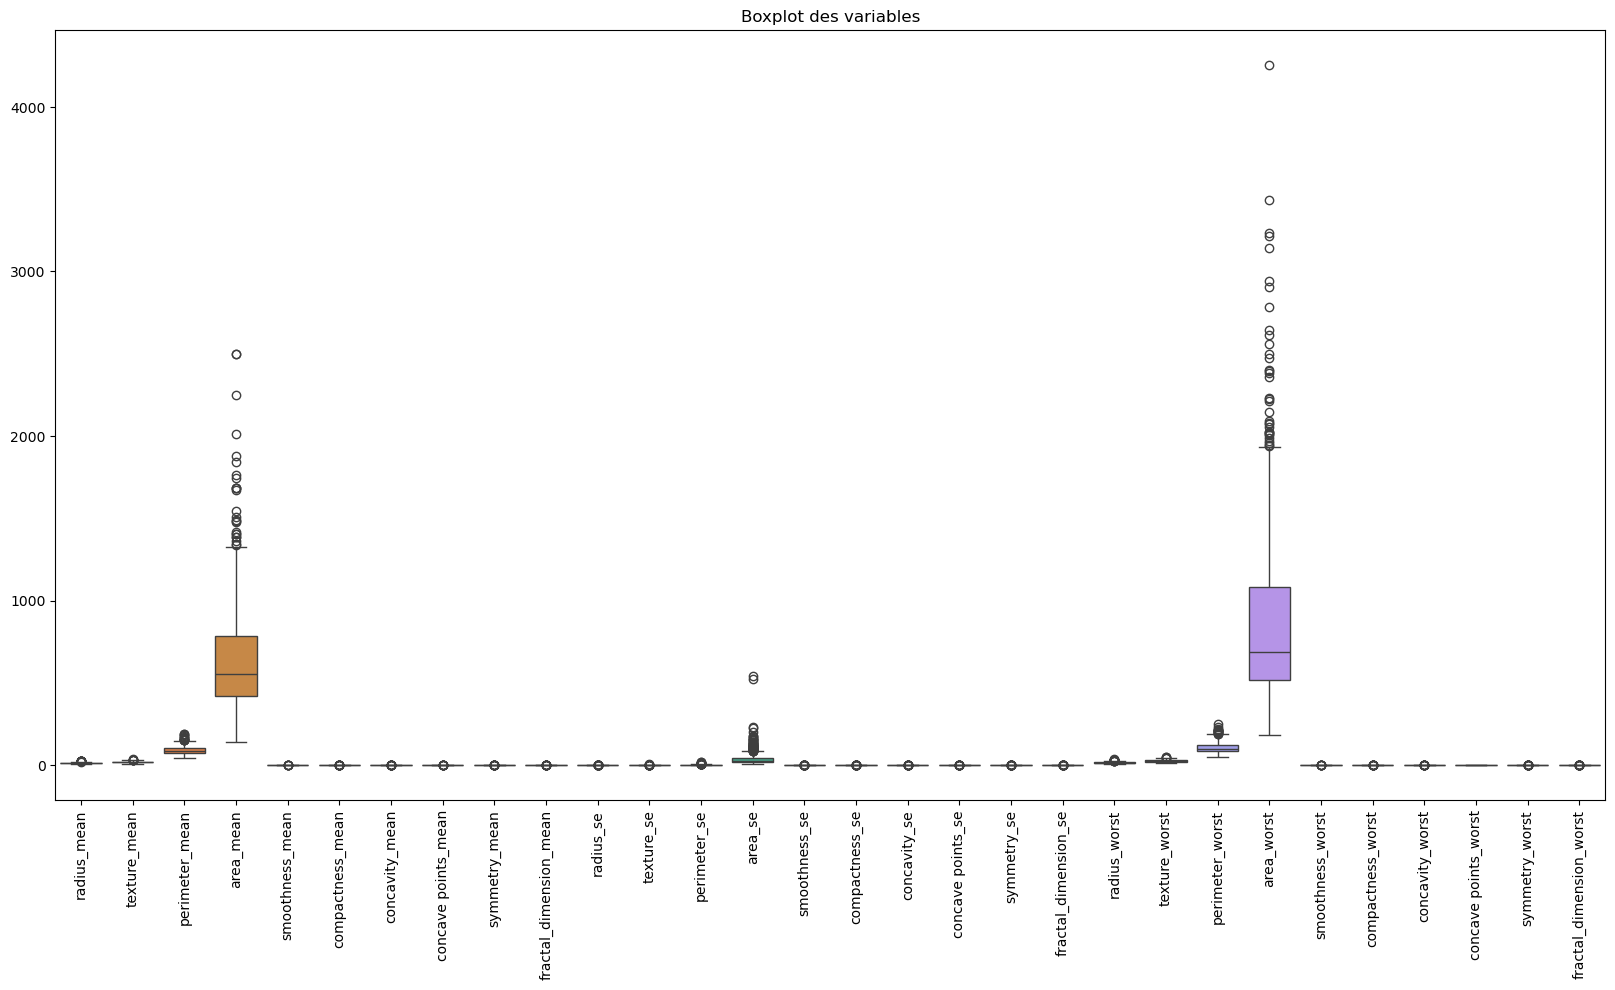

In [277]:
# Boxplot pour visualiser la distribution des variables
plt.figure(figsize=(20,10))
sns.boxplot(data=bc[features])
plt.xticks(rotation=90)
plt.title('Boxplot des variables')
plt.show()


Interprétation : Le boxplot des variables montre que les variables  "area_mean" et "area_worst" présentent des valeurs très éloignées de la majorité des données qui sont des outliers.

# Phase 3 : Data Preparation

In [280]:
#Supprimer les doublons
bc.drop_duplicates(inplace=True)

In [281]:
# Vérifier valeurs manquantes
missing = bc.isnull().sum()
print("Colonnes avec valeurs manquantes :",missing )

Colonnes avec valeurs manquantes : id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


Interpritation : Pas des valeurs manquants aprés suppression de la colonne Unnamed.

In [283]:
X = bc.drop('diagnosis', axis=1)
y = bc['diagnosis']


### Détection des outliers

In [285]:
X1= X.drop('id', axis=1)
Q1 = X1.quantile(0.25)
Q3 = X1.quantile(0.75)
IQR = Q3 - Q1

outliers = ((X1 < (Q1 - 1.5 * IQR)) | (X1 > (Q3 + 1.5 * IQR)))
print(outliers.sum())



radius_mean                14
texture_mean                7
perimeter_mean             13
area_mean                  25
smoothness_mean             6
compactness_mean           16
concavity_mean             18
concave points_mean        10
symmetry_mean              15
fractal_dimension_mean     15
radius_se                  38
texture_se                 20
perimeter_se               38
area_se                    65
smoothness_se              30
compactness_se             28
concavity_se               22
concave points_se          19
symmetry_se                27
fractal_dimension_se       28
radius_worst               17
texture_worst               5
perimeter_worst            15
area_worst                 35
smoothness_worst            7
compactness_worst          16
concavity_worst            12
concave points_worst        0
symmetry_worst             23
fractal_dimension_worst    24
dtype: int64


In [286]:
# Nombre total d’outliers
total_outliers = outliers.sum().sum()

# Nombre total de valeurs dans le dataset
total_values = bc.shape[0] * bc.shape[1]

# Pourcentage des outliers
percentage_outliers = (total_outliers / total_values) * 100

print("Nombre total d'outliers :", total_outliers)
print("Nombre total de valeurs :", total_values)
print(f"Pourcentage d'outliers : {percentage_outliers:.2f}%")

Nombre total d'outliers : 608
Nombre total de valeurs : 18208
Pourcentage d'outliers : 3.34%


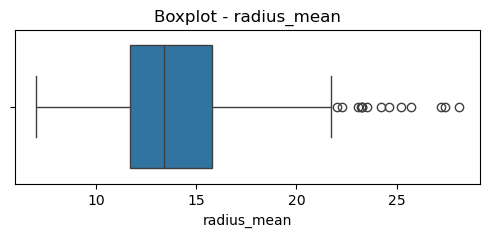

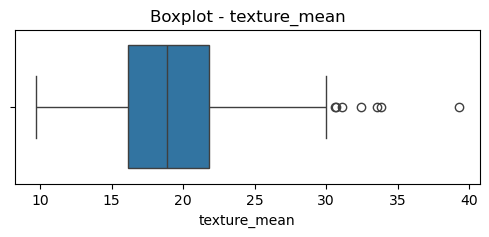

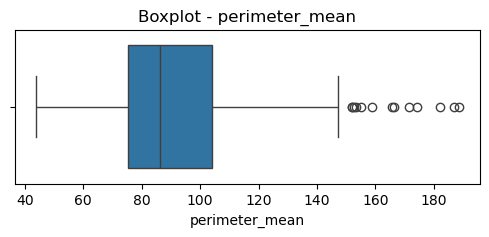

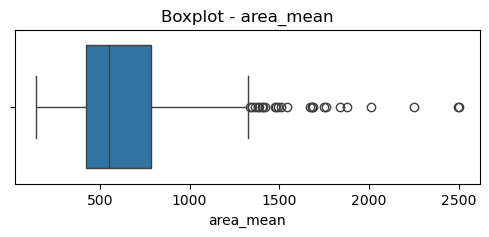

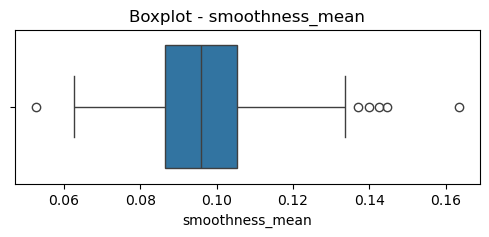

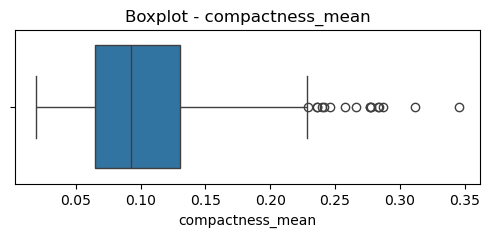

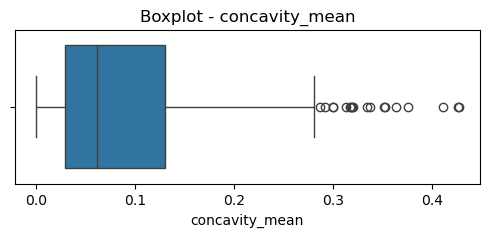

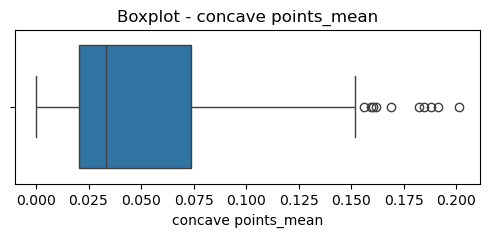

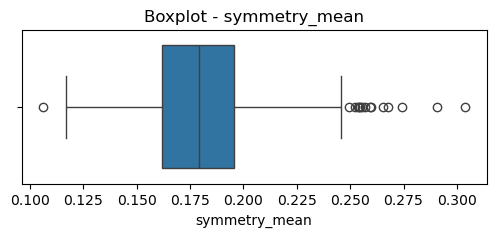

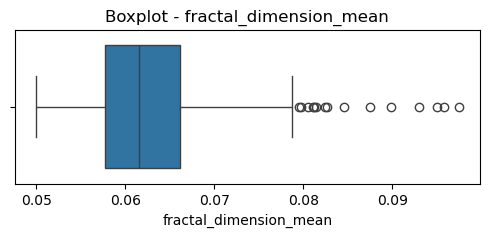

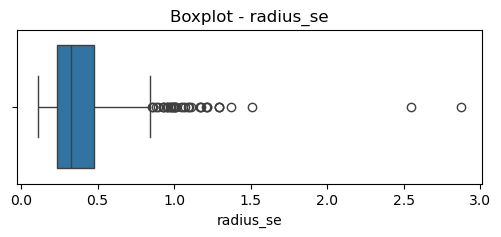

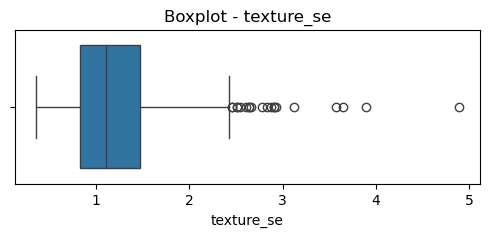

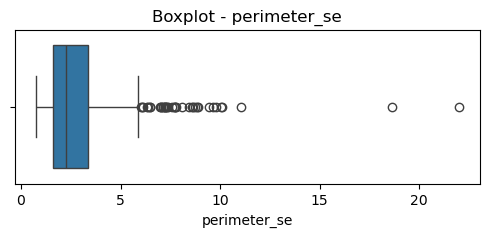

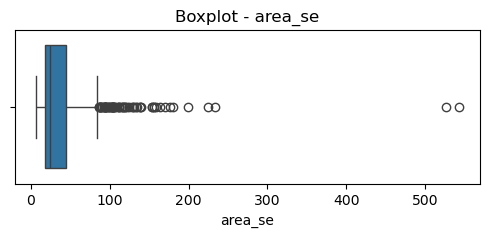

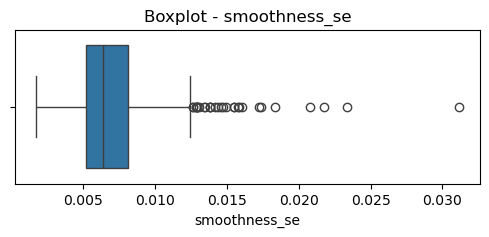

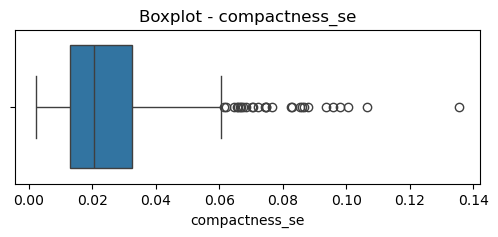

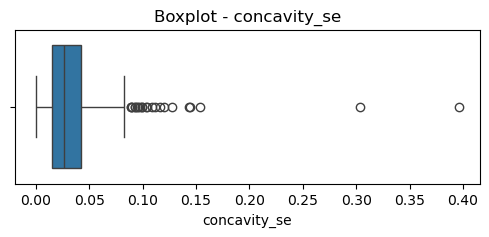

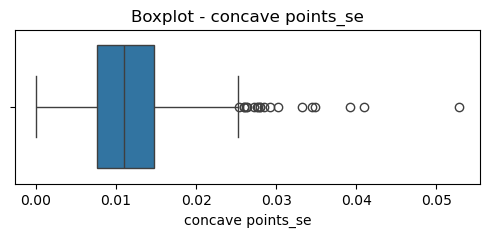

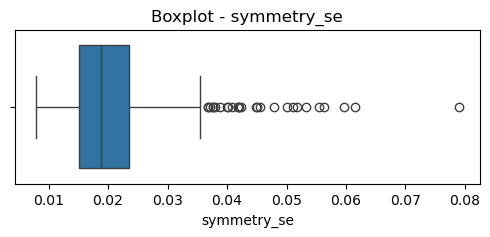

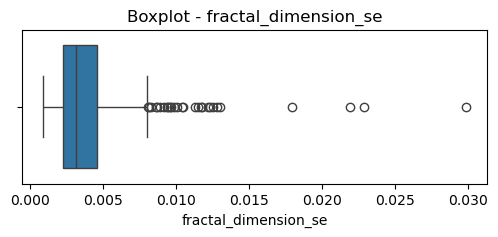

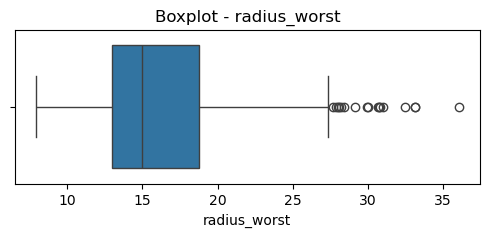

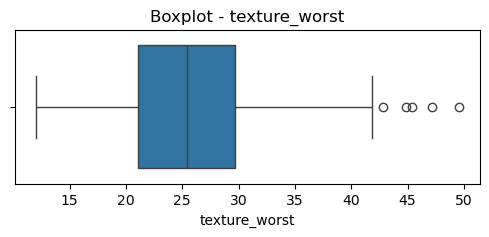

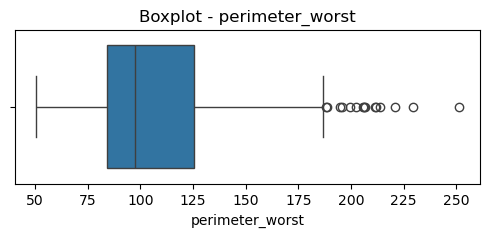

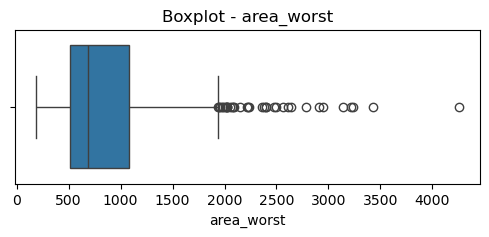

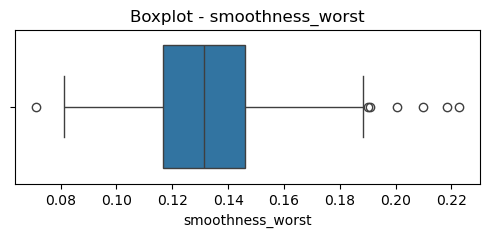

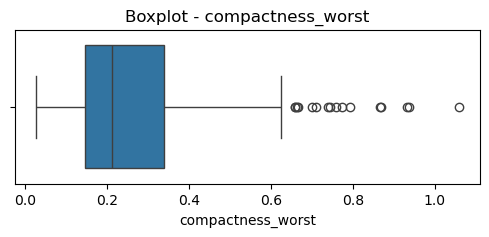

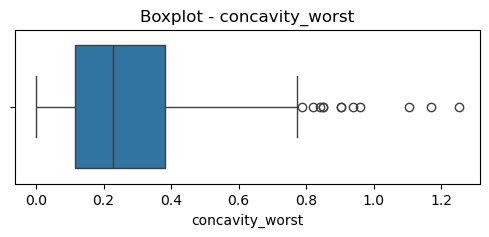

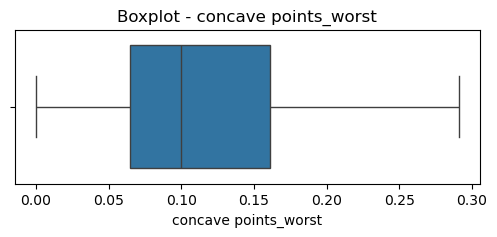

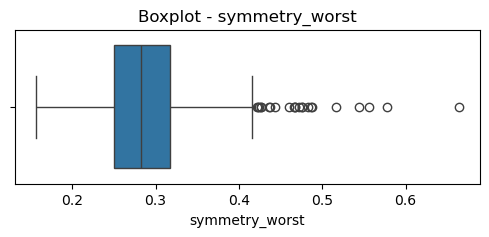

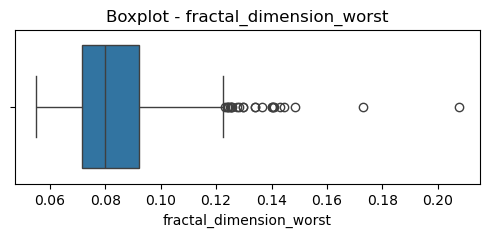

In [287]:
#Visualisation

for col in X1.columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=bc[col])
    plt.title(f"Boxplot - {col}")
    plt.show()


In [301]:
# Indices des lignes à garder
rows_to_keep = ~outliers.any(axis=1)

# Nouveau dataset sans outliers
X_clean = X[rows_to_keep]
y_clean = y[rows_to_keep]

print("Nouvelles dimensions :", X_clean.shape)

print("Nouvelles dimensions :", X_clean.shape)
print("Nouvelles dimensions y :", y_clean.shape)

Nouvelles dimensions : (398, 31)
Nouvelles dimensions : (398, 31)
Nouvelles dimensions y : (398,)


In [303]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

In [305]:
#Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (318, 31)
X_test  : (80, 31)
y_train : (318,)
y_test  : (80,)
